# Module 6: measured thermal response and P/PI modeling
Ricky Huang and Xavier Zhu · Phys 39

## tl;dr
Provisional directional susceptibilities are **0.49545 (heat)** and **0.14142 (cool) °C/PWM**. The reference H3 time constant is **73.03 s**; the six run estimates span **60.86–75.50 s**. P droop follows the provisional model within **0.025–0.229 °C**. Matched simulated PI removes most endpoint error; larger Ki overshoots. **Physical PI evidence is missing.**

## Context & Methods
This is a rerunnable analysis companion to the course memo, not a final submission. It uses unchanged Module 4/5 CSVs and the official v3 solver. Exact methods, units and caveats are in `docs/module_notes/module_06_p_pi_model.md`.

### Key Assumptions
Directional slopes come from provisional endpoint windows. One common time constant is adopted from H3. H=1 is an arbitrary normalization; C and Pu are not independently measured. The v3 command is continuous PWM; measured firmware output is integer PWM. No physical PI measurement is synthesized.

### 1. Setup and source loading
Run this notebook with the project's .venv after installing `python/analysis/requirements.txt`. The next cell reruns the full analysis and validates raw-source windows and P summary values.

In [1]:
from pathlib import Path
import sys, os, io, contextlib, importlib.util, json, html
from IPython.display import display, Image, HTML
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Module_4/data').is_dir())
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/phys39-mpl')
spec = importlib.util.spec_from_file_location('module_06_analysis', ROOT / 'python/analysis/module_06_analysis.py')
analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(analysis)
with contextlib.redirect_stdout(io.StringIO()):
    results = analysis.main()
def show_table(rows, columns):
    header = ''.join('<th>'+html.escape(label)+'</th>' for key,label in columns)
    body = ''
    for row in rows:
        vals = [row.get(key) for key,label in columns]
        values = ['not reached / not applicable' if v is None else f'{v:.4f}' if isinstance(v,float) else str(v) for v in vals]
        body += '<tr>'+''.join('<td>'+html.escape(v)+'</td>' for v in values)+'</tr>'
    display(HTML('<table><thead><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))
def figure(name):
    display(Image(filename=str(ROOT / 'docs/figures/module_06' / (name+'.png')), width=950))
print('Analysis completed; inputs and official v3 hashes are preserved in data/module_06/analysis_results.json.')

Analysis completed; inputs and official v3 hashes are preserved in data/module_06/analysis_results.json.


## Data
### 2. Source preview and directional calibration
The ten selected windows each contain 40 samples. Source code specifies 1000 ADC readings per reported temperature. This does not independently prove the firmware version used for every record. Raw records retain out-of-course-range endpoint exceptions.

Run,Direction,PWM magnitude,Selected endpoint (C),Raw source
H0,HEAT,0,23.44,Module_4/data/module_04_heating_0pct_pwm0_20260928_112039_906848.csv
H1,HEAT,11,28.31,Module_4/data/module_04_heating_25pct_pwm11_20260928_102552_858326.csv
H2,HEAT,23,34.62,Module_4/data/module_04_heating_50pct_pwm23_20260928_103051_243607.csv
H3,HEAT,34,40.42,Module_4/data/module_04_heating_75pct_pwm34_20260928_103941_134734.csv
H4,HEAT,45,45.37,Module_4/data/module_04_heating_max_pwm45_20260928_100550_571289.csv
C0,COOL,0,23.44,Module_4/data/module_04_cooling_0pct_pwm0_20260928_112013_141346.csv
C1,COOL,24,20.44,Module_4/data/module_04_cooling_25pct_pwm24_20260928_104957_896611.csv
C2,COOL,48,16.99,Module_4/data/module_04_cooling_50pct_pwm48_20260928_105744_249371.csv
C3,COOL,72,13.40,Module_4/data/module_04_cooling_75pct_pwm72_20260928_110449_677478.csv
C4,COOL,96,9.99,Module_4/data/module_04_cooling_max_pwm96_20260928_101439_464642.csv


Direction,chi (C/PWM),Fit intercept (C),Slope without max endpoint
HEAT,0.4954,23.2349,0.5023
COOL,0.1414,23.6400,0.1399


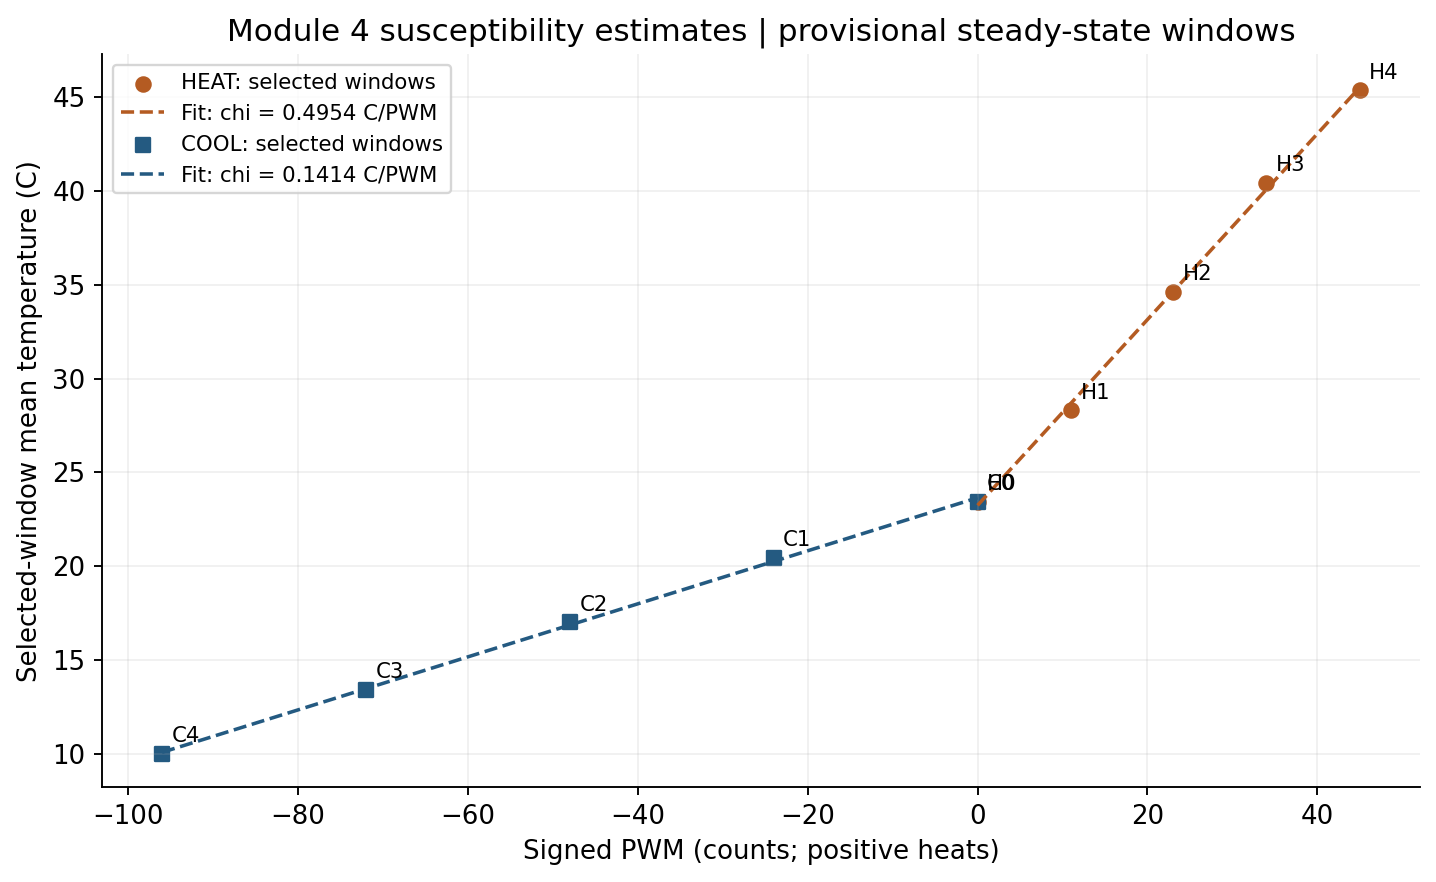

In [2]:
show_table(analysis.read_csv(ROOT/'data/module_04/steady_state.csv'), [('run_id','Run'),('direction','Direction'),('pwm','PWM magnitude'),('steady_temperature_C','Selected endpoint (C)'),('source_csv','Raw source')])
show_table(results['slopes'], [('direction','Direction'),('chi_C_per_PWM','chi (C/PWM)'),('fit_intercept_C','Fit intercept (C)'),('chi_excluding_max_endpoint_C_per_PWM','Slope without max endpoint')])
figure('01_susceptibility')

## Results
### 3. Time constants
Estimate the first 63.2% crossing from the final constant-command segment, interpolating adjacent samples. Endpoint sensitivity is not a confidence interval. Cross-run differences include temperature-dependent behavior, endpoint drift and non-exponential dynamics. H3 supplies the common model time constant.

Run,tau (s),Endpoint sensitivity lower (s),Endpoint sensitivity upper (s)
H1,68.2975,61.4707,70.0287
H2,60.8599,60.2589,61.7084
H3,73.0274,72.4868,73.7492
C1,75.5013,75.1495,77.1148
C2,65.7562,63.6055,68.5623
C3,60.8585,60.7830,60.9240


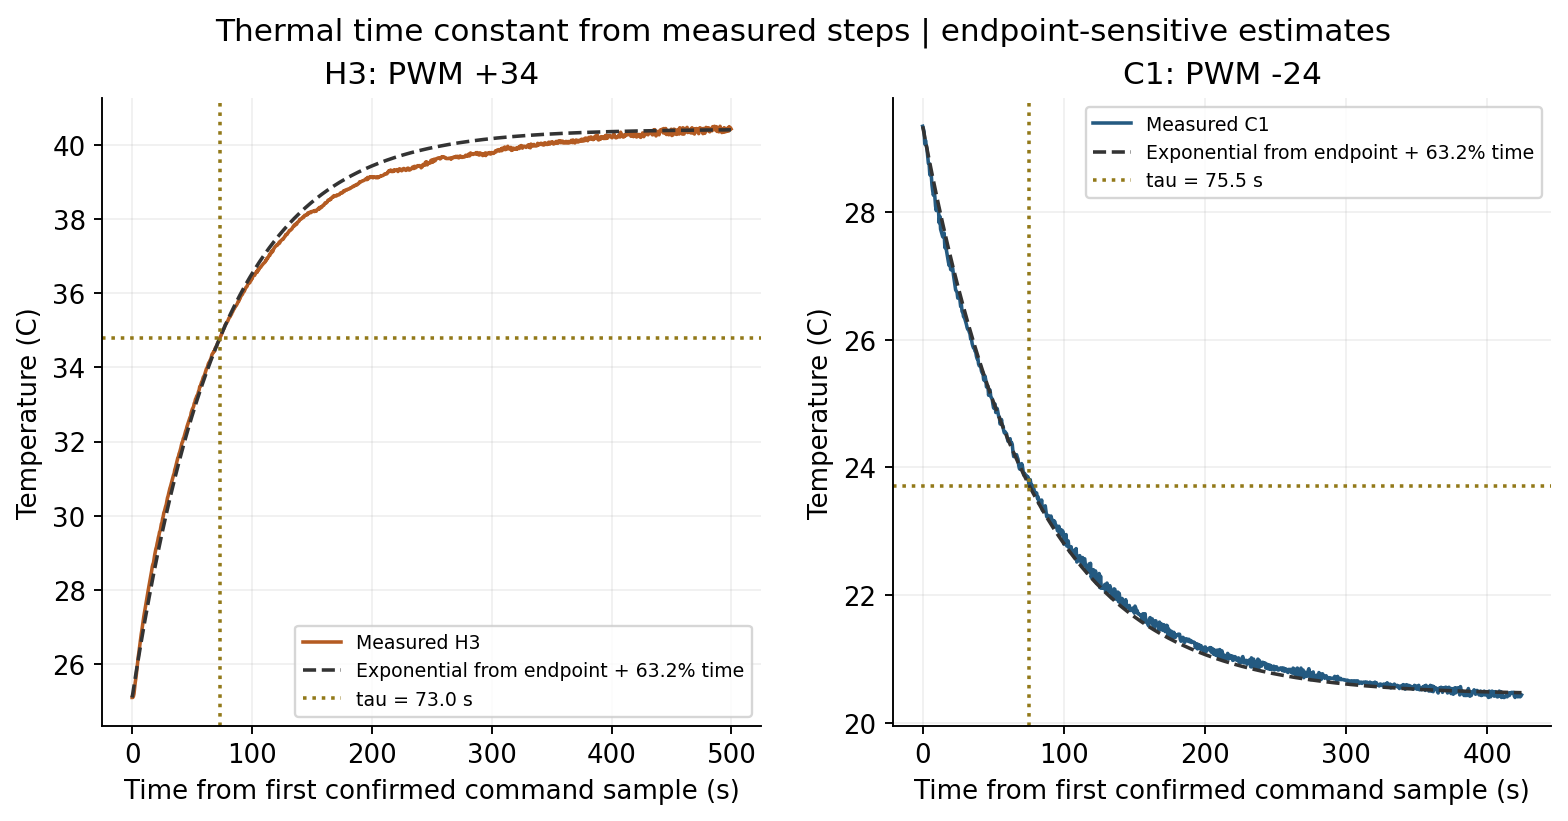

In [3]:
show_table(results['steps'], [('run_id','Run'),('tau_interpolated_s','tau (s)'),('endpoint_sensitivity_min_s','Endpoint sensitivity lower (s)'),('endpoint_sensitivity_max_s','Endpoint sensitivity upper (s)')])
figure('02_time_constants')

### 4. Open-loop validation
H3 is calibration reuse because it supplies tau. C1 checks transfer of that tau, although its endpoint contributes to the cooling calibration. Predictions use command sign, ambient 23.44 C and measured initial temperatures.

Run,Predicted final (C),Measured endpoint (C),RMSE (C)
H3,40.2852,40.4205,0.1802
C1,20.0460,20.4428,0.4451


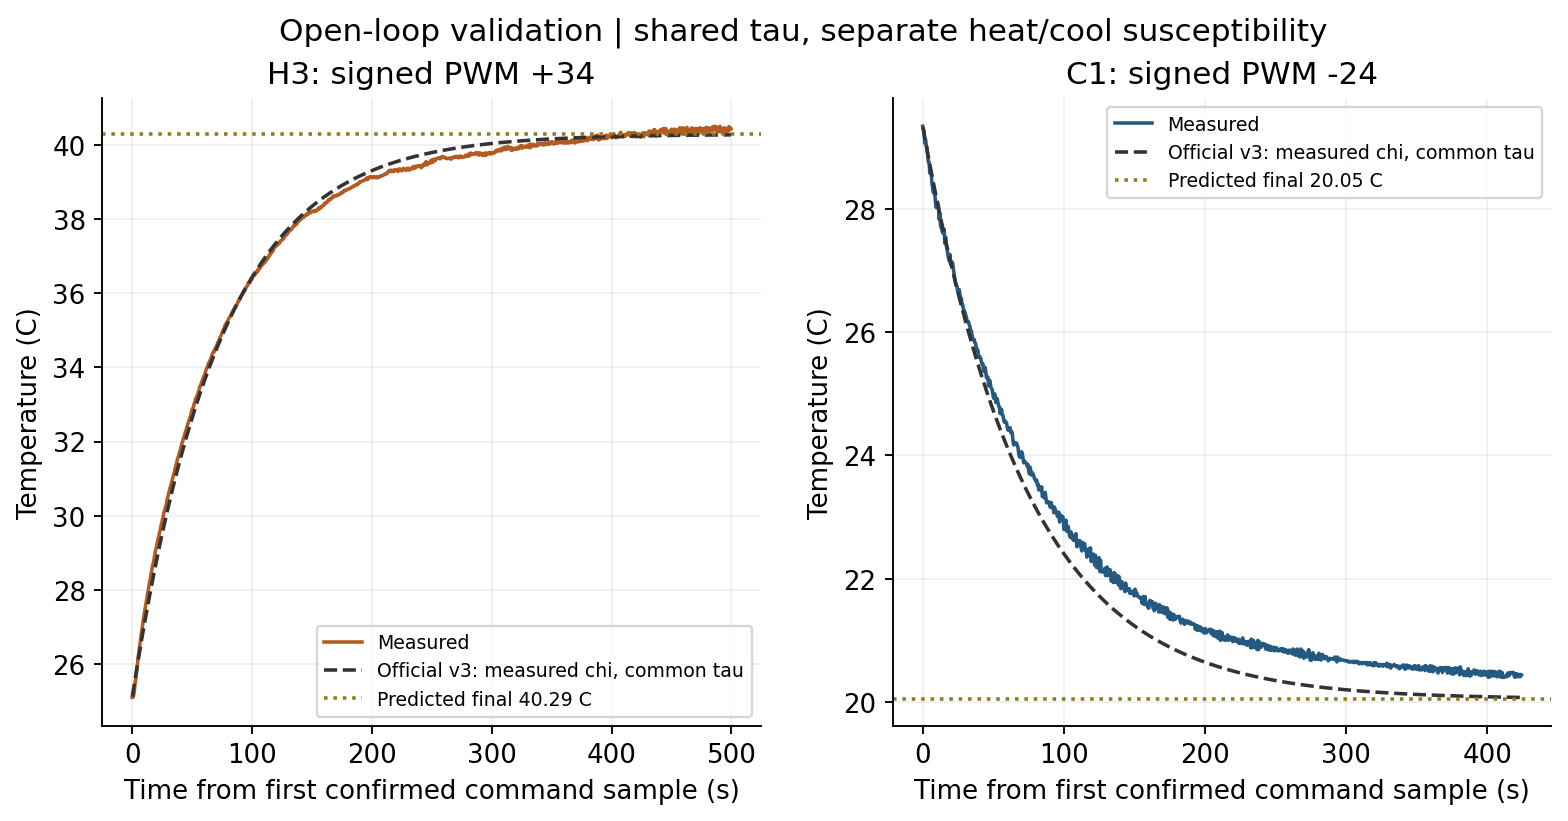

In [4]:
show_table(results['open_loop'], [('run_id','Run'),('predicted_final_C','Predicted final (C)'),('measured_final_20s_C','Measured endpoint (C)'),('trace_RMSE_C','RMSE (C)')])
figure('03_open_loop_comparison')

### 5. P-control droop and dynamics
Use heating susceptibility, the same 23.1885 C ambient reference, and the actual Module 5 gains. The first P-active sample may still report the previous firmware PWM; simulation commands act without serial latency or integer rounding.

Kp (PWM/C),L,Measured droop (C),Predicted droop (C),Predicted tau_cl (s)
0.2500,0.1239,6.0000,6.0608,64.9790
0.5000,0.2477,5.2300,5.4592,58.5285
1.0000,0.4954,4.5022,4.5549,48.8332
2.0000,0.9909,3.2305,3.4213,36.6807
4.0000,1.9818,2.2600,2.2844,24.4912


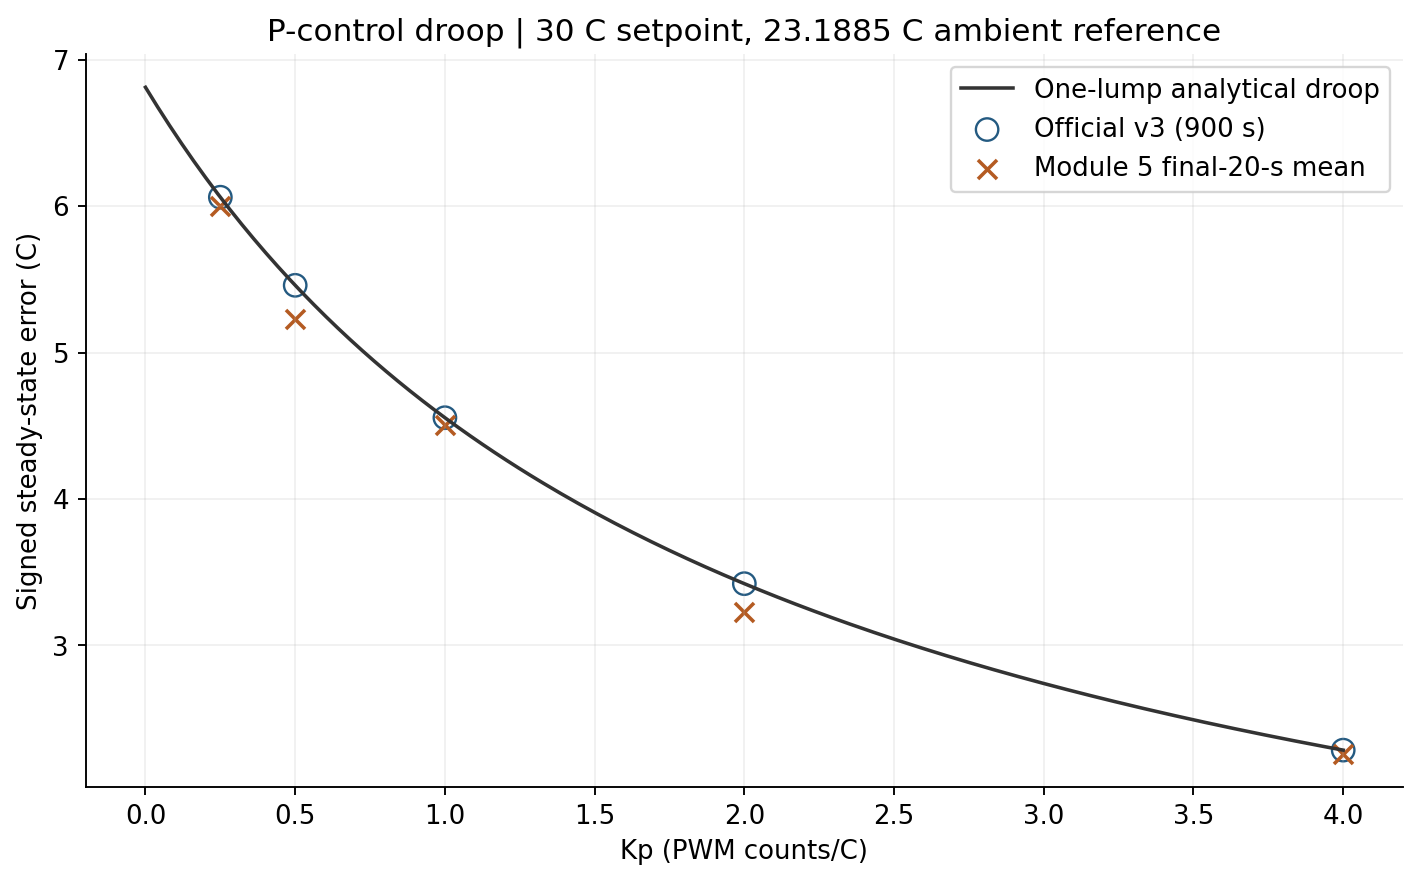

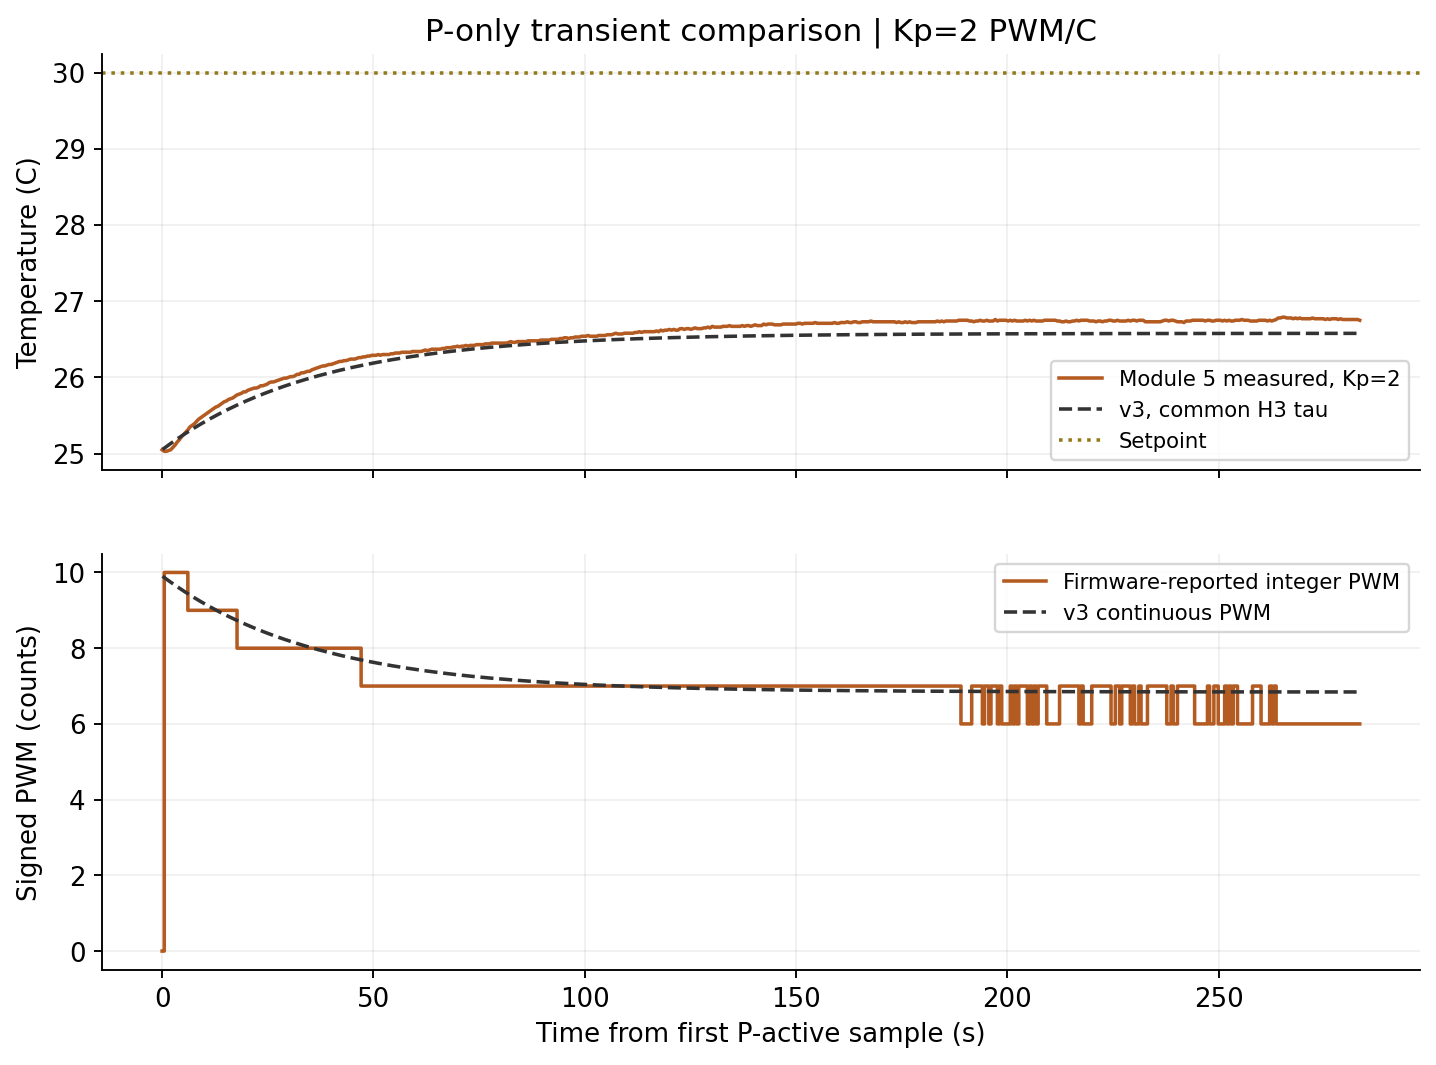

In [5]:
show_table(results['p_comparison'], [('Kp','Kp (PWM/C)'),('loop_gain','L'),('measured_droop_C','Measured droop (C)'),('predicted_droop_C','Predicted droop (C)'),('closed_loop_tau_s','Predicted tau_cl (s)')])
figure('04_p_droop')
figure('05_p_transient')

### 6. Matched simulated P/PI
All settings are identical apart from Ki. Initial integral state is zero. The two PI examples are overdamped (Ki=0.01) and underdamped (Ki=0.08); both are unsaturated. P does not reach 90% of the initial-to-setpoint change or the setpoint tolerance because of droop. Errors reported below are finite-duration errors at 1800 s. These are not physical-controller results.

Case,Ki (PWM/(C s)),PI damping ratio,Error at 1800 s (C),Overshoot (C),Target settling (s)
P,0,not reached / not applicable,3.4213,0.0000,not reached / not applicable
PI_overdamped,0.0100,1.6549,0.0234,0.0000,1164.2000
PI_underdamped,0.0800,0.5851,-0.0000,0.8960,225.7000


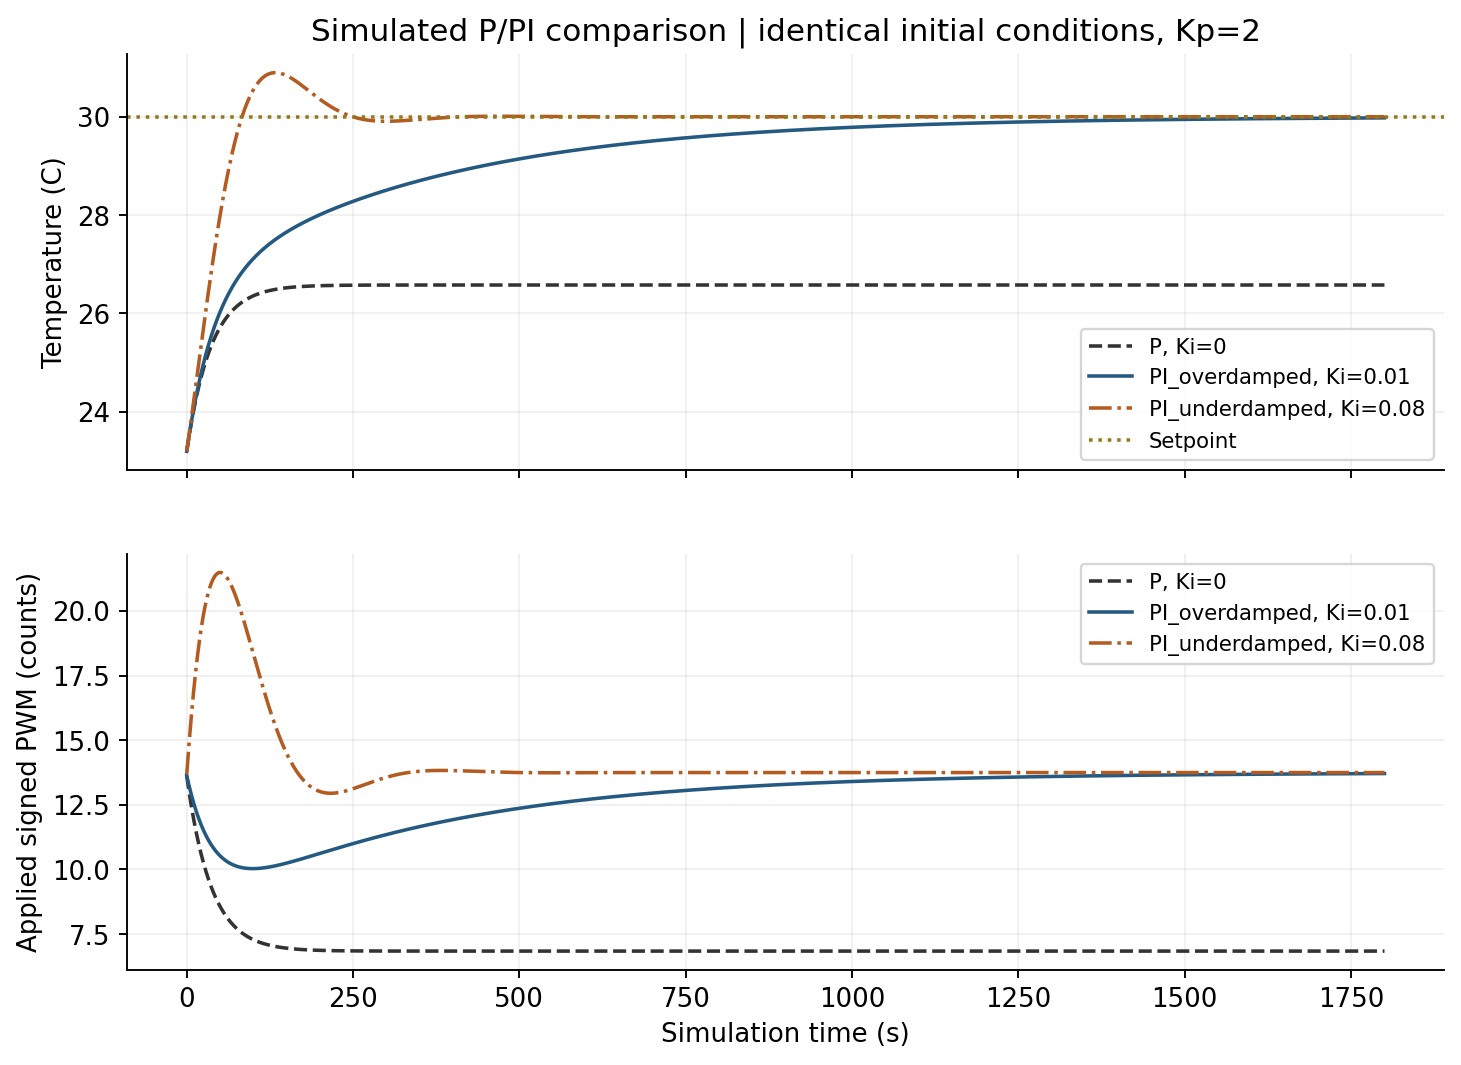

In [6]:
show_table(results['simulation_metrics'], [('case','Case'),('Ki','Ki (PWM/(C s))'),('zeta','PI damping ratio'),('final_droop_C','Error at 1800 s (C)'),('overshoot_C','Overshoot (C)'),('settling_2pct_of_initial_offset_s','Target settling (s)')])
figure('06_p_pi_simulation')

### 7. Saturation and windup
Simulation only: unreachable 60 C setpoint until t=400 s, then 30 C, with PWM limit 15. This is not an instruction to run the physical TEC at 60 C. Conditional integration prevents excessive stored drive and improves recovery.

Anti-windup,Integral PWM at switch,T at 1400 s (C)
True,0.0000,30.0000
False,983.3916,30.6202


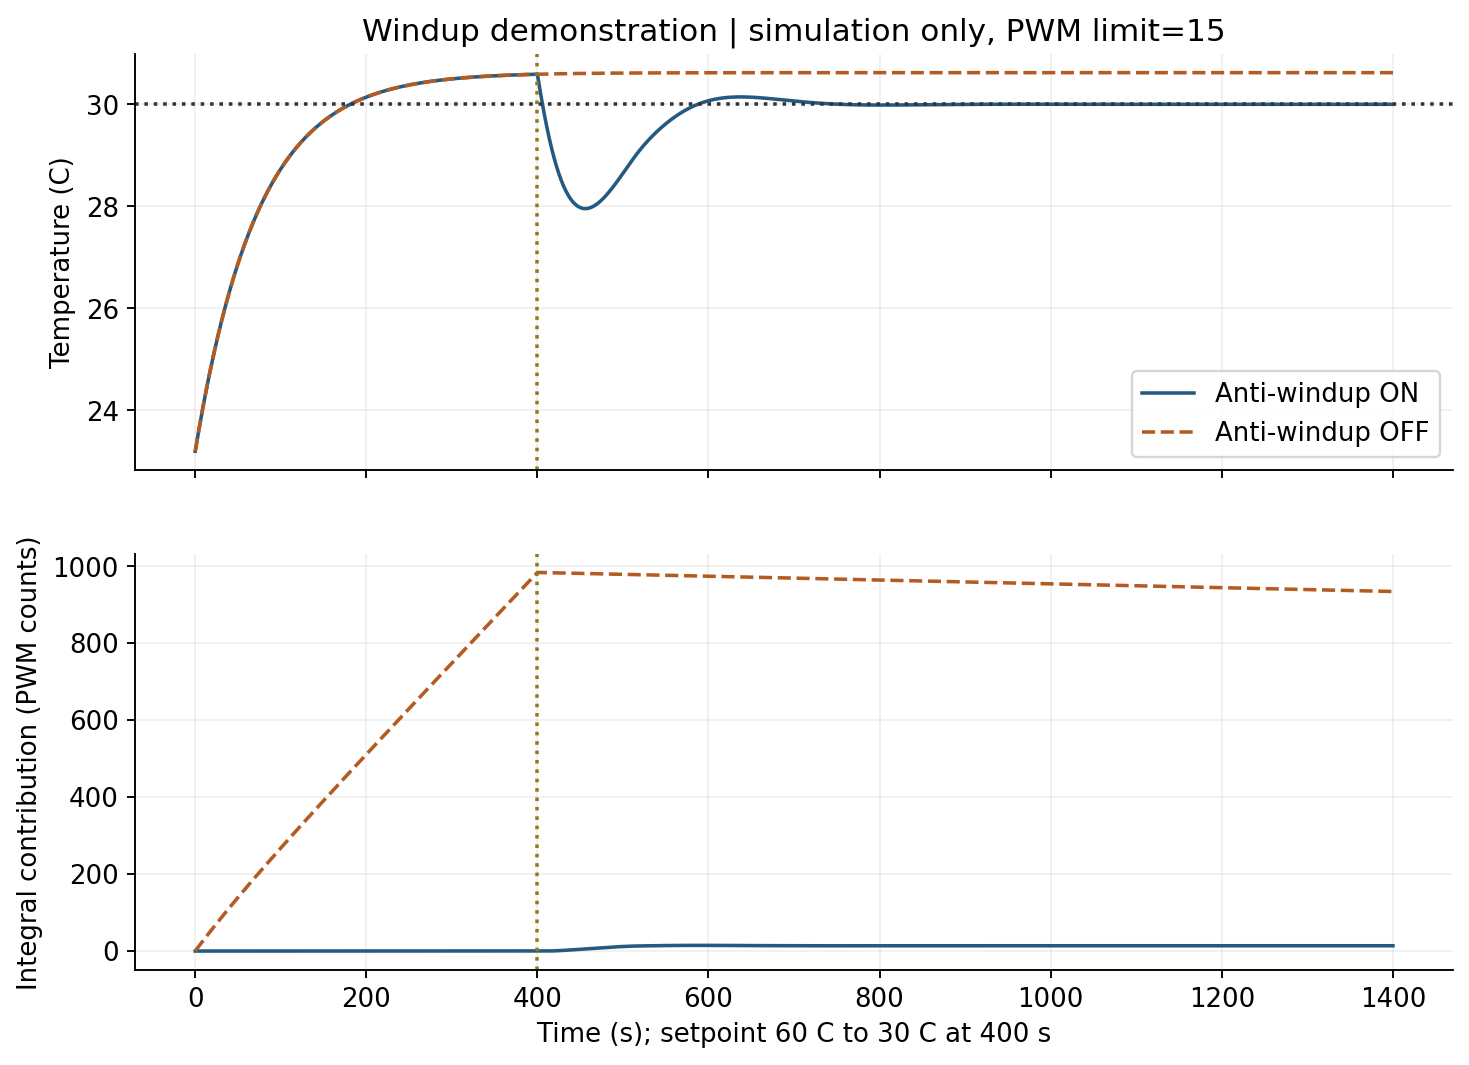

In [7]:
show_table(results['windup'], [('anti_windup','Anti-windup'),('integral_PWM_at_switch','Integral PWM at switch'),('final_temperature_C','T at 1400 s (C)')])
figure('07_windup_simulation')

### 8. Numerical checks
Compare 0.1 s against 0.05 s. Open-loop and P trajectories are also checked against analytical exponential solutions. Null analytical comparisons mean not evaluated for PI, not zero error.

In [8]:
show_table(results['numerical_checks'], [('case','Case'),('max_error_to_analytic_C','Maximum analytical error (C)'),('max_dt_halving_difference_C','Maximum dt-halving change (C)')])
assert max(c['max_dt_halving_difference_C'] for c in results['numerical_checks']) < 0.004
assert all(abs(p['simulated_final_droop_C'] - p['predicted_droop_C']) < 1e-4 for p in results['p_comparison'])
print('Numerical checks passed.')

Case,Maximum analytical error (C),Maximum dt-halving change (C)
open_loop_H3,0.0038,0.0019
open_loop_C1,0.0023,0.0012
P_Kp_0.25,0.0002,0.0001
P_Kp_0.5,0.0004,0.0002
P_Kp_1.0,0.0009,0.0004
P_Kp_2.0,0.0017,0.0009
P_Kp_4.0,0.0034,0.0017
P,not reached / not applicable,0.0009
PI_overdamped,not reached / not applicable,0.0012
PI_underdamped,not reached / not applicable,0.0034


Numerical checks passed.


## Takeaways
The provisional one-lump model captures the stable P droop trend and much of the measured transient response. Increasing Kp reduces droop and response time in the ideal model without creating oscillations. PI stores sustaining drive, allowing zero asymptotic error in an attainable, unsaturated equilibrium, but larger Ki can cause overshoot. Anti-windup matters when actuator limits prevent the requested command.

The next required evidence is a matched physical P/PI experiment, instructor-reviewed control implementation and required Module 5 onset evidence. Module 4 steady-state limitations still require review. The draft A3 is not submission-ready and the local work has not been committed/pushed.

Sources: `data/module_04/steady_state.csv`, all referenced raw Module 4 CSVs, `Module_5/data/part_04_droop_comparison.csv`, its raw P traces, official v3 source. Exact source hashes and settings: `data/module_06/analysis_results.json`.